In [1]:
path = r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\parquet-data\lev-15\data\lev-15_merged.parquet"

# import 
import pandas as pd
import polars as pl
import missingno as msgo
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import Data and filter
pdf = pl.read_parquet(path)
display(f"Before Filtering the shape {pdf.shape}")
pdf = pdf.filter(
    pl.col('State') == '23'
)
display(f"After Filter the shape {pdf.shape}")


'Before Filtering the shape (2095624, 28)'

'After Filter the shape (112840, 28)'

In [3]:
# str -> int 
pdf = pdf.with_columns(
    [pl.col(col).cast(pl.Int16, strict=False) for col in pdf.columns]
)

display(pdf.schema)

Schema([('Survey_Name', Int16),
        ('Year', Int16),
        ('FSU_Serial_No', Int16),
        ('Sector', Int16),
        ('State', Int16),
        ('NSS_Region', Int16),
        ('District', Int16),
        ('Stratum', Int16),
        ('Sub_stratum', Int16),
        ('Panel', Int16),
        ('Sub_sample', Int16),
        ('FOD_Sub_Region', Int16),
        ('Sample_SU_No', Int16),
        ('Sample_Sub_Division_No', Int16),
        ('Second_Stage_Stratum_No', Int16),
        ('Sample_Household_No', Int16),
        ('Questionnaire_No', Int16),
        ('VISIT', Int16),
        ('LEVEL', Int16),
        ('SECTION', Int16),
        ('TIME_TAKEN', Int16),
        ('MONTHLY_CONSUMPTION_EXP', Int16),
        ('ONLINE_EXPENDITURE', Int16),
        ('INFORMANT_CODE', Int16),
        ('RESPONSE_CODE', Int16),
        ('HOUSEHOLD_SIZE', Int16),
        ('VISIT_MONTH', Int16),
        ('MULTIPLIER', Int16)])

In [4]:
pdf.columns

['Survey_Name',
 'Year',
 'FSU_Serial_No',
 'Sector',
 'State',
 'NSS_Region',
 'District',
 'Stratum',
 'Sub_stratum',
 'Panel',
 'Sub_sample',
 'FOD_Sub_Region',
 'Sample_SU_No',
 'Sample_Sub_Division_No',
 'Second_Stage_Stratum_No',
 'Sample_Household_No',
 'Questionnaire_No',
 'VISIT',
 'LEVEL',
 'SECTION',
 'TIME_TAKEN',
 'MONTHLY_CONSUMPTION_EXP',
 'ONLINE_EXPENDITURE',
 'INFORMANT_CODE',
 'RESPONSE_CODE',
 'HOUSEHOLD_SIZE',
 'VISIT_MONTH',
 'MULTIPLIER']

In [5]:
pdf[[ 'TIME_TAKEN',
 'MONTHLY_CONSUMPTION_EXP',
 'ONLINE_EXPENDITURE',
 'INFORMANT_CODE',
 'RESPONSE_CODE',
 'HOUSEHOLD_SIZE',
 'VISIT_MONTH',]].describe()

statistic,TIME_TAKEN,MONTHLY_CONSUMPTION_EXP,ONLINE_EXPENDITURE,INFORMANT_CODE,RESPONSE_CODE,HOUSEHOLD_SIZE,VISIT_MONTH
str,f64,f64,f64,f64,f64,f64,f64
"""count""",112838.0,83292.0,84624.0,84630.0,84630.0,84630.0,33802.0
"""null_count""",2.0,29548.0,28216.0,28210.0,28210.0,28210.0,79038.0
"""mean""",38.46752,11077.973395,375.918841,2.173036,1.171334,4.599102,21918.089107
"""std""",9.478504,5483.850373,1269.484409,7.309197,0.480948,2.152221,8140.32728
"""min""",11.0,430.0,0.0,1.0,1.0,1.0,12024.0
"""25%""",30.0,7210.0,0.0,1.0,1.0,3.0,12024.0
"""50%""",40.0,10000.0,0.0,1.0,1.0,4.0,22024.0
"""75%""",45.0,14000.0,0.0,2.0,1.0,6.0,32024.0
"""max""",110.0,32500.0,30000.0,99.0,9.0,31.0,32024.0


In [6]:
cols = [
 'MONTHLY_CONSUMPTION_EXP',
 'ONLINE_EXPENDITURE',]

pdf = pdf[cols]

display(f"Desire Filter shape {pdf.shape}")


'Desire Filter shape (112840, 2)'

In [7]:
colors = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59']  
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

palette = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59', '#ccff33', '#ff36ab', '#e0fbfc', '#3772ff', '#45062e']  
sns.set_palette(palette)

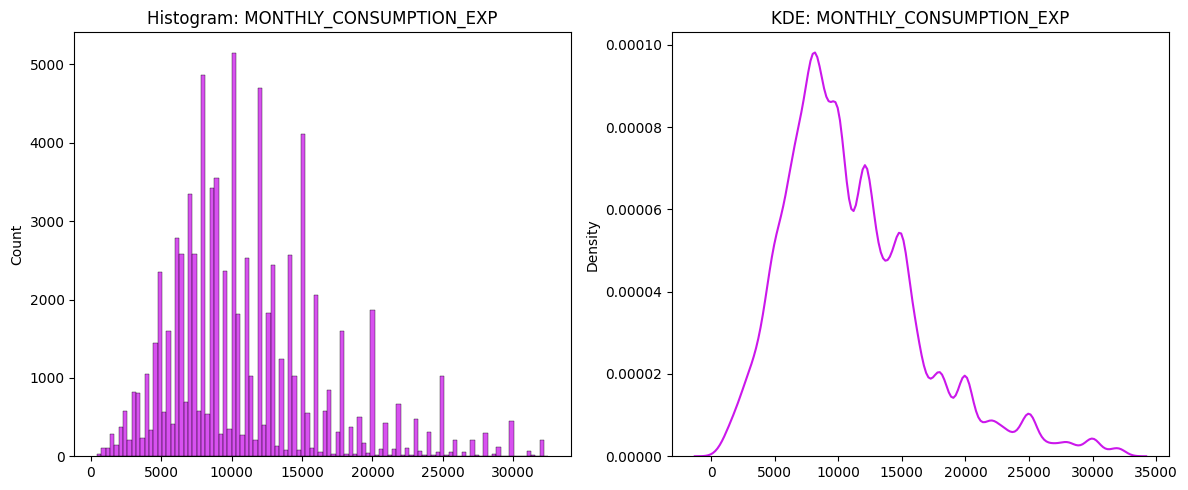

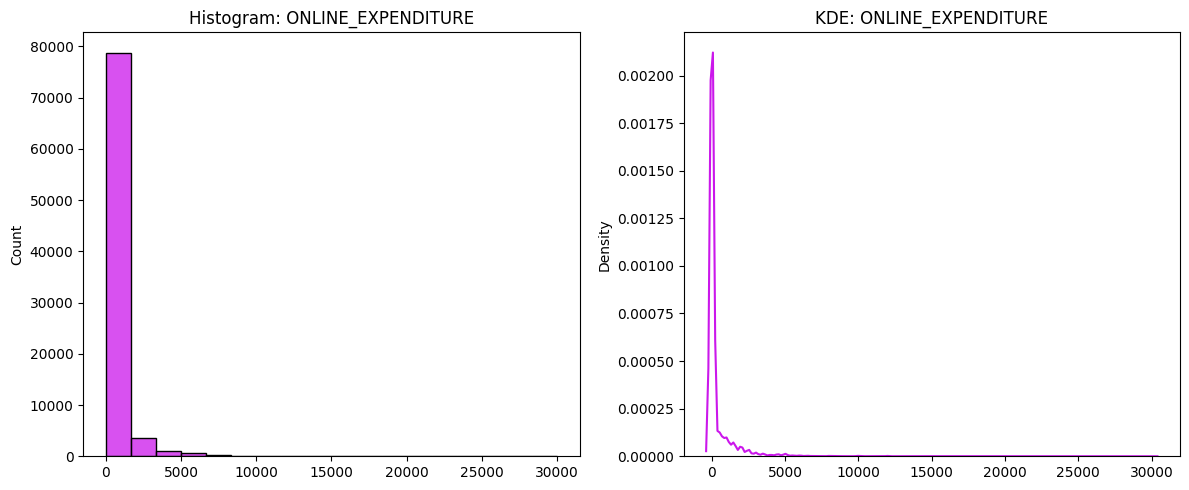

In [19]:
for col in ['MONTHLY_CONSUMPTION_EXP', 'ONLINE_EXPENDITURE',]:
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    # Histogram on the first subplot
    sns.histplot(pdf[col], ax=ax[0])
    ax[0].set_title(f"Histogram: {col}")

    # KDE plot on the second subplot
    sns.kdeplot(pdf[col], ax=ax[1])
    ax[1].set_title(f"KDE: {col}")

    plt.tight_layout()
    plt.show()

In [24]:
pdf['ONLINE_EXPENDITURE'].describe(percentiles=[0.5, 0.6, 0.7, 0.8, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 0.999, 0.9999]).to_pandas()

,statistic,value
0,count,84624.000000
1,null_count,28216.000000
2,mean,375.918841
3,std,1269.484409
4,min,0.000000
5,50%,0.000000
6,60%,0.000000
7,70%,0.000000
8,80%,120.000000
9,90%,1200.000000
